## Naive Bayes : 


- ##### Works on conditional probability



### Naive : Features
### Bayes : Bayes Theorem

## Conditional Probability: 

P(E) = F.O / T.O

F.O : Favorable outcome

T.O : Total outcome


### Independent Probability : 
#### - Probability that does not depend upon previous outcome/probability. Example: rolling dice and getting 6

### Dependent Probability : 
#### - Probability that depends upon previous outcome/probability. Example: pulling out red ball from a box of multiple balls where after a ball is pull, it is not returned to the box

## Bayes theorem formula: 


#### P(A|B) = P(B/A)*P(A)
#### P(B|A) = P(A/B)*P(B)

#### P(A|B) = P(B|A)

#### P(A/B) = P(B/A)*P(A)/P(B)

#### Example: 


P(yes/x1x2) = (p(yes) * p(x1/yes) * p(x2/yes))/(p(x1) * p(x2))

### Gaussian Naive Bayes : Input data is almost normal distribution 
### Bernoulli Naive Bayes : Every columns are boolean (One hat encoded type)
### Multinomial Naive Bayes : text type data, discrete data, no normal distribution

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [3]:
dataset = pd.read_csv("data/placement.csv")

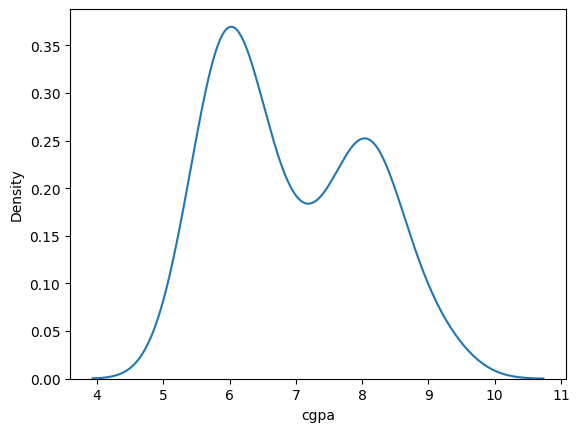

In [10]:
sns.kdeplot(data=dataset["cgpa"])
plt.show()

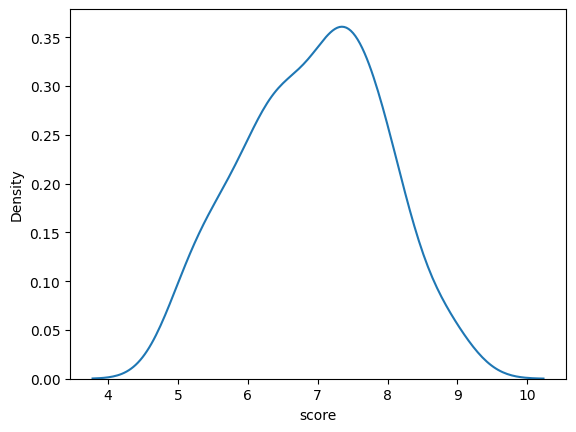

In [11]:
sns.kdeplot(data=dataset["score"])
plt.show()

In [5]:
dataset.isnull().sum()

cgpa      0
score     0
placed    0
dtype: int64

<Axes: xlabel='cgpa', ylabel='score'>

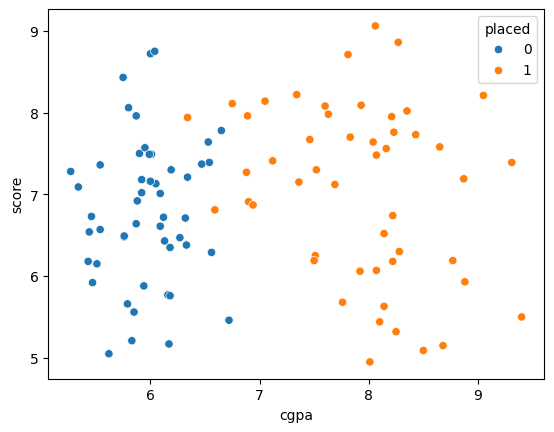

In [6]:
sns.scatterplot(x = "cgpa", y = "score", data = dataset, hue = "placed")

In [7]:
x = dataset.iloc[:,:-1]
y = dataset["placed"]

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

In [13]:
gnb = GaussianNB()
gnb.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [14]:
gnb.score(x_test, y_test), gnb.score(x_train, y_train)

(1.0, 0.975)

In [15]:
mnb = MultinomialNB()
mnb.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [16]:
mnb.score(x_test, y_test), mnb.score(x_train, y_train)

(0.75, 0.7375)

In [17]:
bnb = BernoulliNB()
bnb.fit(x_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [18]:
bnb.score(x_test, y_test), bnb.score(x_train, y_train)

(0.5, 0.5)

c:\Users\taksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


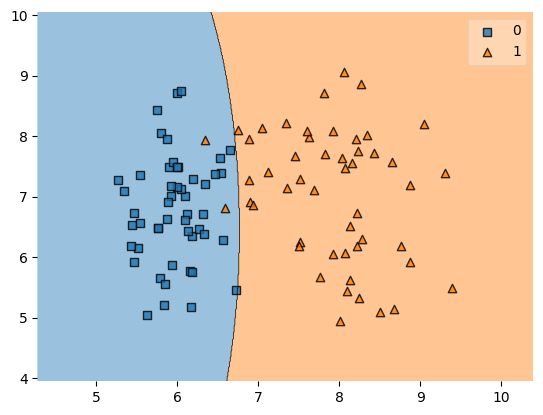

In [20]:
plot_decision_regions(x.to_numpy(), y.to_numpy(), clf = gnb)
plt.show()

c:\Users\taksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


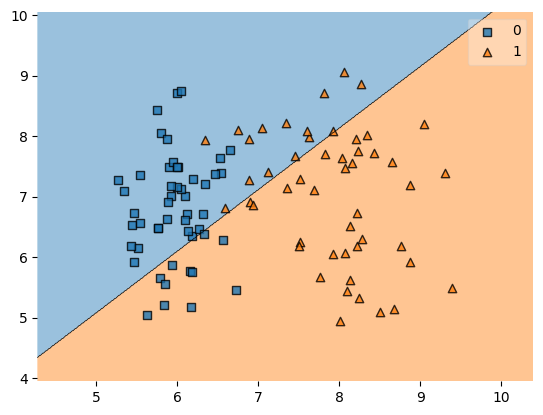

In [21]:
plot_decision_regions(x.to_numpy(), y.to_numpy(), clf = mnb)
plt.show()

c:\Users\taksh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(


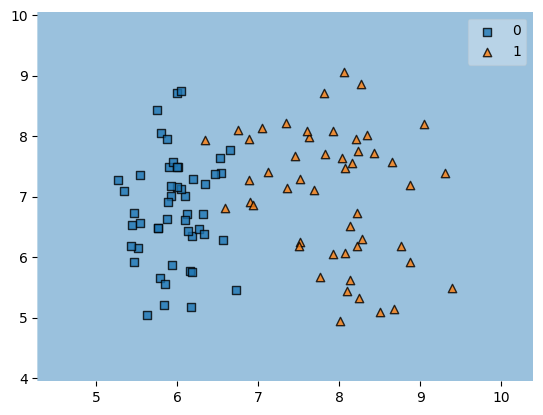

In [22]:
plot_decision_regions(x.to_numpy(), y.to_numpy(), clf = bnb)
plt.show()